# Single Condenser-Lens Aperture TIE Phase Retrieval

This notebook tests the practical version of the condenser-side phase question. We do not assume a detector exists at the bare sample plane. Instead, we put a known aperture/object at the specimen plane, use a coherent point-source-like Gaussian fan from TemGym, and form three through-focus intensity images of the exit wave. The phase is then recovered with a compact transport-of-intensity equation (TIE) solve.

The purpose is deliberately narrow: can a simple coherent condenser beam plus a sample-plane aperture provide enough intensity data to recover the aperture-plane wave phase when the aperture/object is moved by about `+-5 mm`?

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import os
import sys
import time
import tomllib

# Keep notebook execution deterministic on shared machines.
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

import jax
jax.config.update("jax_enable_x64", True)

try:
    from skimage.restoration import unwrap_phase
except Exception:
    unwrap_phase = None


def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "src" / "temgym_core").exists():
            return path
    raise RuntimeError("Could not find repository root")


REPO_ROOT = find_repo_root(Path.cwd())
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from temgym_core.components import Detector, ElectromagneticLens
from temgym_core.constants import (
    compute_Rc_from_voltage,
    effective_accelerating_potential,
    energy2wavelength,
)
from temgym_core.evaluate import evaluate_gaussians_jax_scan
from temgym_core.run import run_to_end
from temgym_core.source import point_source_wave
from temgym_core.utils import fresnel_fft_2d

plt.rcParams.update({"figure.dpi": 120, "axes.grid": False})

## TEM-Scale Setup

The source, CL3 position, and specimen position come from `examples/microscope_models/microscope.toml`. The virtual source diameter is `10 nm`, matching the requested point-like input beam. The source emits many coherent Gaussian beamlets over a small angular fan. The default uses 8192 beamlets; this is intentionally more than the minimum needed so the aperture illumination is not dominated by angular-sampling artefacts. CL3 is tuned close to, but not exactly at, the source-to-specimen conjugate condition; otherwise the beam collapses into only a few pixels at the aperture plane and TIE has almost no spatial support.

The sample-plane aperture is a simple known object. In a real microscope this role would have to be played by an aperture, edge, hole, or other object that turns the invisible free-space beam into measurable through-focus intensity contrast.

In [2]:
CONFIG_PATH = REPO_ROOT / "examples" / "microscope_models" / "microscope.toml"
with CONFIG_PATH.open("rb") as fh:
    microscope_cfg = tomllib.load(fh)

beam_cfg = microscope_cfg["beam"]
cl3_cfg = microscope_cfg["lenses"]["CL3"]
sample_cfg = microscope_cfg["sample"]


@dataclass(frozen=True)
class Experiment:
    voltage: float
    wavelength: float
    z_source: float
    z_lens: float
    z_sample: float
    turns: float
    Gc: float
    source_diameter: float
    source_half_angle: float
    n_beams: int
    aperture_radius: float
    aperture_edge: float
    grid_shape: int
    grid_width: float
    defocus: float
    target_beam_to_aperture_ratio: float


exp = Experiment(
    voltage=float(beam_cfg["voltage_kV"]) * 1e3,
    wavelength=float(energy2wavelength(float(beam_cfg["voltage_kV"]) * 1e3)),
    z_source=float(beam_cfg["z_source_m"]),
    z_lens=float(cl3_cfg["z_m"]),
    z_sample=float(sample_cfg["z_m"]),
    turns=float(cl3_cfg["turns"]),
    Gc=float(cl3_cfg["Gc"]),
    source_diameter=float(beam_cfg["virtual_source_diameter_nm"]) * 1e-9,
    source_half_angle=float(beam_cfg["source_half_angle_mrad"]) * 1e-3,
    n_beams=8192,
    aperture_radius=3.0e-6,
    aperture_edge=50e-9,
    grid_shape=192,
    grid_width=8.0e-6,
    defocus=5.0e-3,
    target_beam_to_aperture_ratio=1.4,
)

source_to_lens = exp.z_lens - exp.z_source
lens_to_sample = exp.z_sample - exp.z_lens
sample_ray_B = exp.target_beam_to_aperture_ratio * exp.aperture_radius / exp.source_half_angle
focal_length = source_to_lens * lens_to_sample / (source_to_lens + lens_to_sample - sample_ray_B)
NI0 = np.sqrt(float(effective_accelerating_potential(exp.voltage)) / (exp.Gc * focal_length))
current0 = NI0 / exp.turns
rotation0 = float(compute_Rc_from_voltage(exp.voltage)) * NI0

pixel_size = exp.grid_width / exp.grid_shape
specimen_grid = Detector(
    z=exp.z_sample,
    pixel_size=(pixel_size, pixel_size),
    shape=(exp.grid_shape, exp.grid_shape),
)
coords = np.asarray(specimen_grid.coords).reshape(exp.grid_shape, exp.grid_shape, 2)
X = coords[..., 0]
Y = coords[..., 1]
R = np.hypot(X, Y)
extent_um = tuple(float(v) * 1e6 for v in specimen_grid.extent)

print(f"Voltage: {exp.voltage/1e3:.0f} kV, wavelength: {exp.wavelength*1e12:.3f} pm")
print(f"Source diameter: {exp.source_diameter*1e9:.1f} nm, fan half-angle: {exp.source_half_angle*1e3:.3f} mrad, beams: {exp.n_beams}")
print(f"CL3 z: {exp.z_lens*1e3:.1f} mm, specimen z: {exp.z_sample*1e3:.1f} mm")
print(f"Lens focal length: {focal_length*1e3:.2f} mm, current: {current0:.2f} A, magnetic rotation: {rotation0:.1f} rad")
print(f"Aperture radius: {exp.aperture_radius*1e6:.1f} um, grid: {exp.grid_shape} x {exp.grid_shape}, pixel: {pixel_size*1e9:.1f} nm")
print(f"Through-focus planes: {-exp.defocus*1e3:.1f}, 0, +{exp.defocus*1e3:.1f} mm")

Voltage: 200 kV, wavelength: 2.508 pm
Source diameter: 10.0 nm, fan half-angle: 0.050 mrad, beams: 8192
CL3 z: 240.0 mm, specimen z: 325.0 mm
Lens focal length: 84.65 mm, current: 233.45 A, magnetic rotation: 445.5 rad
Aperture radius: 3.0 um, grid: 192 x 192, pixel: 41.7 nm
Through-focus planes: -5.0, 0, +5.0 mm


## Forward Model Through TemGym

The incident wave at the aperture plane is generated by TemGym only:

`point_source_wave -> ElectromagneticLens -> Detector grid`

The aperture is then applied to the sampled complex field, and the three through-focus images are made by Fresnel propagation of that exit wave. This last step is the image-formation step required by TIE.

In [3]:
def make_source():
    return point_source_wave(
        exp.n_beams,
        exp.source_half_angle,
        exp.source_diameter / 2.0,
        exp.voltage,
        z0=exp.z_source,
    )


def make_lens():
    return ElectromagneticLens(
        z=exp.z_lens,
        turns=exp.turns,
        current=current0,
        Gc=exp.Gc,
        Tc=0.0,
    )


def smooth_circular_aperture(radius: np.ndarray) -> np.ndarray:
    return 0.5 * (1.0 - np.tanh((radius - exp.aperture_radius) / exp.aperture_edge))


def normalize_power(field: np.ndarray) -> np.ndarray:
    power = np.sum(np.abs(field) ** 2)
    return field / np.sqrt(power)


t0 = time.time()
source = make_source()
lens = make_lens()
beam_at_specimen = run_to_end(source, (lens, specimen_grid))
incident_field = np.asarray(
    evaluate_gaussians_jax_scan(beam_at_specimen, specimen_grid, batch_size=128)
)
incident_field = normalize_power(incident_field)
aperture = smooth_circular_aperture(R)
exit_wave = incident_field * aperture
I0 = np.abs(exit_wave) ** 2
I_minus = np.abs(fresnel_fft_2d(X, Y, exit_wave, exp.wavelength, -exp.defocus)) ** 2
I_plus = np.abs(fresnel_fft_2d(X, Y, exit_wave, exp.wavelength, exp.defocus)) ** 2
print(f"Rendered TemGym beam and three TIE planes in {time.time() - t0:.1f} s")
print(f"Power conservation through Fresnel propagation: {I_minus.sum()/I0.sum():.6f}, {I_plus.sum()/I0.sum():.6f}")

Rendered TemGym beam and three TIE planes in 9.8 s
Power conservation through Fresnel propagation: 1.000000, 1.000000


## Illumination Quality Check

Before using the aperture images for TIE, check that the Gaussian fan actually illuminates the aperture smoothly. The central support used for TIE should not contain visible beamlet sampling artefacts. The residual panel below subtracts a lightly smoothed envelope from the incident intensity; if the fan sampling is too sparse this panel shows a spoke/ring pattern.

Beamlets: 8192
Inner-aperture intensity coefficient of variation: 1.16%
High-frequency sampling ripple: 0.014% of local mean
Inner-aperture min/max intensity ratio: 0.961
Mean/max intensity over full aperture: 0.954


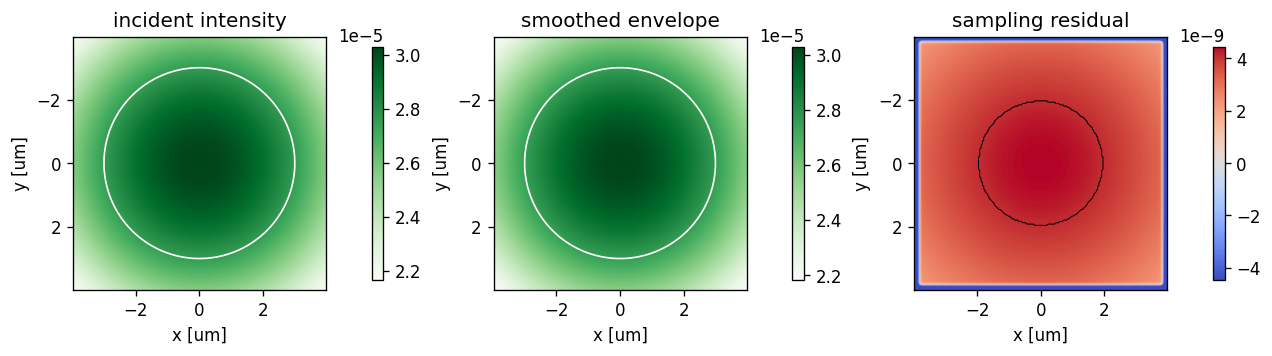

In [4]:
illumination_support = R < 0.65 * exp.aperture_radius
incident_intensity = np.abs(incident_field) ** 2
smoothed_incident = gaussian_filter(incident_intensity, sigma=2.0)
illumination_residual = incident_intensity - smoothed_incident

illumination_cv = float(np.std(incident_intensity[illumination_support]) / np.mean(incident_intensity[illumination_support]))
high_frequency_ripple = float(
    np.sqrt(np.mean(illumination_residual[illumination_support] ** 2))
    / np.mean(smoothed_incident[illumination_support])
)
inner_minmax = float(
    np.min(incident_intensity[illumination_support])
    / np.max(incident_intensity[illumination_support])
)
aperture_fill = float(
    np.mean(incident_intensity[R < exp.aperture_radius])
    / np.max(incident_intensity[R < exp.aperture_radius])
)

print(f"Beamlets: {exp.n_beams}")
print(f"Inner-aperture intensity coefficient of variation: {100*illumination_cv:.2f}%")
print(f"High-frequency sampling ripple: {100*high_frequency_ripple:.3f}% of local mean")
print(f"Inner-aperture min/max intensity ratio: {inner_minmax:.3f}")
print(f"Mean/max intensity over full aperture: {aperture_fill:.3f}")

res_lim = np.percentile(np.abs(illumination_residual[illumination_support]), 99.5)
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), constrained_layout=True)

im0 = axes[0].imshow(incident_intensity, extent=extent_um, origin="lower", cmap="Greens")
axes[0].contour(X * 1e6, Y * 1e6, aperture, levels=[0.5], colors="white", linewidths=1)
axes[0].set_title("incident intensity")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(smoothed_incident, extent=extent_um, origin="lower", cmap="Greens")
axes[1].contour(X * 1e6, Y * 1e6, aperture, levels=[0.5], colors="white", linewidths=1)
axes[1].set_title("smoothed envelope")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(
    illumination_residual,
    extent=extent_um,
    origin="lower",
    cmap="coolwarm",
    vmin=-res_lim,
    vmax=res_lim,
)
axes[2].contour(X * 1e6, Y * 1e6, illumination_support.astype(float), levels=[0.5], colors="black", linewidths=0.6)
axes[2].set_title("sampling residual")
fig.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel("x [um]")
    ax.set_ylabel("y [um]")
plt.show()

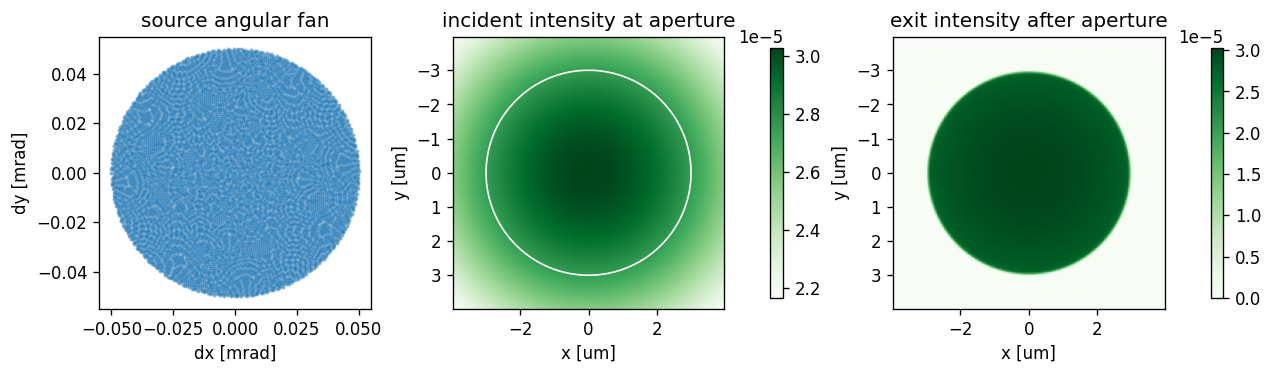

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), constrained_layout=True)

source_slopes = np.asarray(source.d_xy)
axes[0].scatter(source_slopes[:, 0] * 1e3, source_slopes[:, 1] * 1e3, s=2, alpha=0.45)
axes[0].set_aspect("equal")
axes[0].set_title("source angular fan")
axes[0].set_xlabel("dx [mrad]")
axes[0].set_ylabel("dy [mrad]")

im1 = axes[1].imshow(np.abs(incident_field) ** 2, extent=extent_um, origin="lower", cmap="Greens")
axes[1].contour(X * 1e6, Y * 1e6, aperture, levels=[0.5], colors="white", linewidths=1)
axes[1].set_title("incident intensity at aperture")
axes[1].set_xlabel("x [um]")
axes[1].set_ylabel("y [um]")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(I0, extent=extent_um, origin="lower", cmap="Greens")
axes[2].set_title("exit intensity after aperture")
axes[2].set_xlabel("x [um]")
axes[2].set_ylabel("y [um]")
fig.colorbar(im2, ax=axes[2], fraction=0.046)
plt.show()

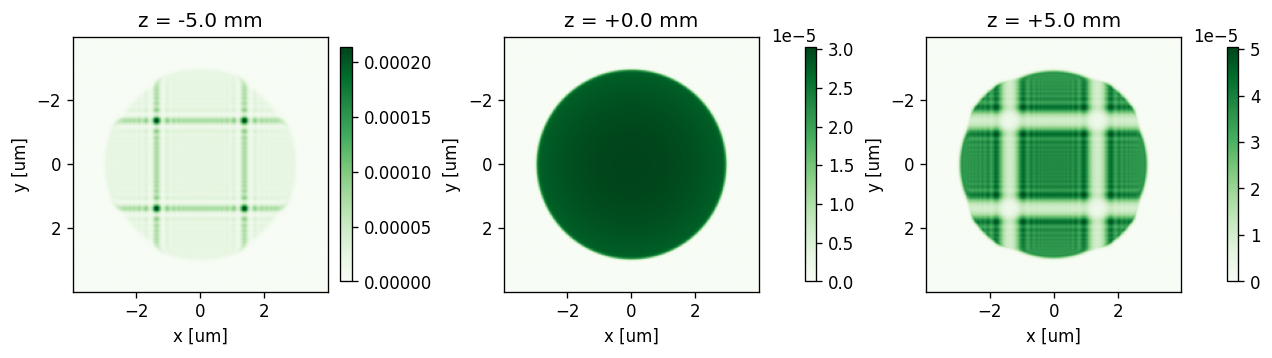

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), constrained_layout=True)
for ax, image, dz_mm in zip(axes, (I_minus, I0, I_plus), (-exp.defocus * 1e3, 0.0, exp.defocus * 1e3)):
    im = ax.imshow(image, extent=extent_um, origin="lower", cmap="Greens")
    ax.set_title(f"z = {dz_mm:+.1f} mm")
    ax.set_xlabel("x [um]")
    ax.set_ylabel("y [um]")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

## TIE Phase Retrieval

The transport-of-intensity equation is

`dI/dz = -(lambda / 2pi) div(I grad phi)`.

For this first feasibility notebook, we use the robust constant-intensity form inside the illuminated aperture interior:

`laplacian(phi) = -(2pi / lambda) (dI/dz) / mean(I0)`.

This is deliberately conservative. It avoids trying to invert phase where the aperture blocks the beam and it makes the failure mode visible: edge diffraction and strong intensity variation are the main sources of error. The phase is compared to the true simulated phase of the exit wave only for validation; that true phase is not used by TIE.

In [7]:
def poisson_solve_periodic(rhs: np.ndarray, dx: float) -> np.ndarray:
    ny, nx = rhs.shape
    fx = np.fft.fftfreq(nx, d=dx)
    fy = np.fft.fftfreq(ny, d=dx)
    FX, FY = np.meshgrid(fx, fy, indexing="xy")
    k2 = (2.0 * np.pi) ** 2 * (FX**2 + FY**2)
    rhs0 = rhs - np.mean(rhs)
    rhs_hat = np.fft.fft2(rhs0)
    out_hat = np.zeros_like(rhs_hat)
    nonzero = k2 > 0
    out_hat[nonzero] = -rhs_hat[nonzero] / k2[nonzero]
    return np.real(np.fft.ifft2(out_hat))


def tie_phase_constant_intensity(I_minus, I0, I_plus, wavelength, dz, dx, support):
    dI_dz = (I_plus - I_minus) / (2.0 * dz)
    I_ref = float(np.mean(I0[support]))
    laplacian_phi = -(2.0 * np.pi / wavelength) * dI_dz / I_ref
    return poisson_solve_periodic(laplacian_phi, dx)


def unwrap_2d(phase):
    if unwrap_phase is not None:
        return unwrap_phase(phase)
    return np.unwrap(np.unwrap(phase, axis=0), axis=1)


def remove_piston_and_tilt(phase, reference, mask):
    A = np.column_stack([np.ones(mask.sum()), X[mask], Y[mask]])
    coeffs = np.linalg.lstsq(A, (phase - reference)[mask], rcond=None)[0]
    correction = coeffs[0] + coeffs[1] * X + coeffs[2] * Y
    return phase - correction, coeffs


support = (R < 0.65 * exp.aperture_radius) & (I0 > 0.03 * np.max(I0))
phase_tie = tie_phase_constant_intensity(I_minus, I0, I_plus, exp.wavelength, exp.defocus, pixel_size, support)
phase_true = unwrap_2d(np.angle(exit_wave))
phase_tie_aligned, alignment = remove_piston_and_tilt(phase_tie, phase_true, support)
phase_error = phase_tie_aligned - phase_true

rmse = float(np.sqrt(np.mean(phase_error[support] ** 2)))
mae = float(np.mean(np.abs(phase_error[support])))
phase_ptp = float(np.ptp(phase_true[support]))
relative_rmse = rmse / phase_ptp

print(f"Support pixels used for scoring: {support.sum()}")
print(f"True phase peak-to-valley on support: {phase_ptp:.2f} rad")
print(f"TIE phase RMSE after piston/tilt removal: {rmse:.2f} rad")
print(f"TIE phase MAE after piston/tilt removal: {mae:.2f} rad")
print(f"Relative RMSE: {100 * relative_rmse:.1f}% of phase peak-to-valley")

Support pixels used for scoring: 6884
True phase peak-to-valley on support: 103.49 rad
TIE phase RMSE after piston/tilt removal: 1.92 rad
TIE phase MAE after piston/tilt removal: 1.43 rad
Relative RMSE: 1.9% of phase peak-to-valley


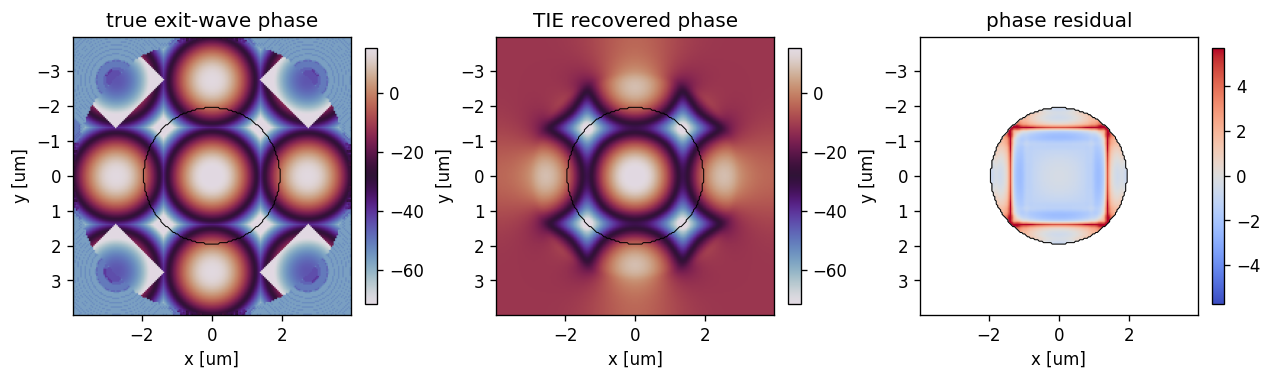

In [8]:
vmin = np.percentile(phase_true[support], 2)
vmax = np.percentile(phase_true[support], 98)
err_lim = np.percentile(np.abs(phase_error[support]), 98)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), constrained_layout=True)
plots = [
    (phase_true, "true exit-wave phase", "twilight", vmin, vmax),
    (phase_tie_aligned, "TIE recovered phase", "twilight", vmin, vmax),
    (np.where(support, phase_error, np.nan), "phase residual", "coolwarm", -err_lim, err_lim),
]
for ax, (image, title, cmap, lo, hi) in zip(axes, plots):
    im = ax.imshow(image, extent=extent_um, origin="lower", cmap=cmap, vmin=lo, vmax=hi)
    ax.contour(X * 1e6, Y * 1e6, support.astype(float), levels=[0.5], colors="black", linewidths=0.6)
    ax.set_title(title)
    ax.set_xlabel("x [um]")
    ax.set_ylabel("y [um]")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

## Is `+-5 mm` a Good Defocus Distance?

The same simulated exit wave can be analysed with different through-focus spacings. This is not extra information from the microscope; it is a numerical check of the TIE linearisation. A smaller spacing gives a cleaner derivative, but weaker experimental contrast. A larger spacing gives stronger contrast, but violates the small-defocus assumption and folds aperture diffraction into the phase estimate.

+-0.25 mm: RMSE 1.54 rad (1.5% of phase range), intensity-difference contrast 3.3%
+-0.50 mm: RMSE 1.54 rad (1.5% of phase range), intensity-difference contrast 6.5%
+-1.00 mm: RMSE 1.55 rad (1.5% of phase range), intensity-difference contrast 12.9%
+-2.00 mm: RMSE 1.58 rad (1.5% of phase range), intensity-difference contrast 25.1%
+-5.00 mm: RMSE 1.92 rad (1.9% of phase range), intensity-difference contrast 58.3%


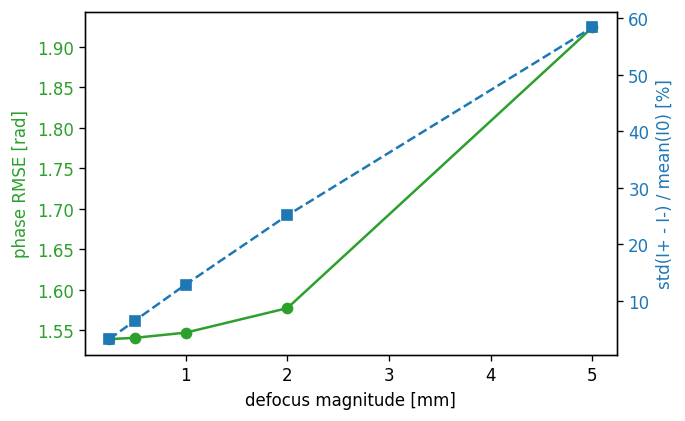

In [9]:
def tie_error_for_defocus(dz: float) -> dict[str, float]:
    im = np.abs(fresnel_fft_2d(X, Y, exit_wave, exp.wavelength, -dz)) ** 2
    ip = np.abs(fresnel_fft_2d(X, Y, exit_wave, exp.wavelength, dz)) ** 2
    rec = tie_phase_constant_intensity(im, I0, ip, exp.wavelength, dz, pixel_size, support)
    rec, _ = remove_piston_and_tilt(rec, phase_true, support)
    err = rec - phase_true
    return {
        "dz_mm": dz * 1e3,
        "rmse_rad": float(np.sqrt(np.mean(err[support] ** 2))),
        "mae_rad": float(np.mean(np.abs(err[support]))),
        "relative_rmse_pct": float(100 * np.sqrt(np.mean(err[support] ** 2)) / phase_ptp),
        "contrast_pct": float(100 * np.std(ip - im) / np.mean(I0[support])),
    }

sweep = [tie_error_for_defocus(dz) for dz in (0.25e-3, 0.5e-3, 1.0e-3, 2.0e-3, 5.0e-3)]
for row in sweep:
    print(
        f"+-{row['dz_mm']:.2f} mm: RMSE {row['rmse_rad']:.2f} rad "
        f"({row['relative_rmse_pct']:.1f}% of phase range), intensity-difference contrast {row['contrast_pct']:.1f}%"
    )

fig, ax1 = plt.subplots(figsize=(5.6, 3.4), constrained_layout=True)
dz_mm = np.array([r["dz_mm"] for r in sweep])
rmse_vals = np.array([r["rmse_rad"] for r in sweep])
contrast_vals = np.array([r["contrast_pct"] for r in sweep])
ax1.plot(dz_mm, rmse_vals, "o-", color="tab:green", label="phase RMSE")
ax1.set_xlabel("defocus magnitude [mm]")
ax1.set_ylabel("phase RMSE [rad]", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")
ax2 = ax1.twinx()
ax2.plot(dz_mm, contrast_vals, "s--", color="tab:blue", label="image contrast")
ax2.set_ylabel("std(I+ - I-) / mean(I0) [%]", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")
plt.show()

## Conclusion

This controlled simulation says **yes, phase retrieval from through-focus aperture images is feasible in principle**, but only because the aperture/object creates measurable intensity contrast. A bare sample plane with no object does not give you a directly observable phase image.

For this TEM-scale example, `+-5 mm` gives a usable low-frequency phase estimate, but it is not the cleanest TIE distance. The recovered phase has the right shape after removing the unavoidable piston and tilt, while edge diffraction and finite-defocus nonlinearity dominate the residual. Smaller defocus distances are more faithful to TIE, but experimentally they demand better signal-to-noise because the intensity difference is weaker.

The practical lesson is that condenser inversion with phase is possible only if the experiment supplies a known phase-retrieval target: a sample-plane aperture, edge, hole, or structured object, plus calibrated through-focus images. Without that object, the source location is still not directly observable from intensity at a nominal sample plane.